In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Global_Mental_Health_Crisis_Index_2026.csv")

print(df.shape)

df.head(10)

(92, 29)


,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,...,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,...,87,1.59,0.2,0.078,Low (<1.5h),1.65,3.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,Mozambique,MOZ,Africa,Low,3.4,4.6,8.2,0.04,0.6,0.1,...,86,2.62,0.4,0.058,Low (<1.5h),1.70,3.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,Ethiopia,ETH,Africa,Low,3.5,4.8,10.2,0.04,1.0,0.1,...,84,10.24,0.4,0.095,Low (<1.5h),1.75,4.7,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
3,Zimbabwe,ZWE,Africa,Low,4.0,5.2,15.4,0.05,0.7,0.1,...,83,1.46,0.5,0.066,Moderate (1.5-2.5h),2.00,4.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
4,Tanzania,TZA,Africa,Low,3.6,4.9,8.6,0.04,0.8,0.1,...,82,5.57,0.4,0.075,Moderate (1.5-2.5h),1.80,4.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
5,Uganda,UGA,Africa,Low,3.5,4.8,12.0,0.08,1.0,0.1,...,81,3.91,0.8,0.093,Moderate (1.5-2.5h),1.75,5.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
6,Lesotho,LSO,Africa,Lower-Middle,4.8,5.8,87.5,0.05,1.1,0.2,...,80,0.23,0.5,0.102,Low (<1.5h),2.40,5.6,2,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
7,Eswatini,SWZ,Africa,Lower-Middle,4.5,5.5,40.5,0.08,1.0,0.2,...,79,0.12,0.8,0.092,Low (<1.5h),2.25,5.7,2,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
8,Ukraine,UKR,Europe,Upper-Middle,6.3,7.1,18.5,3.10,2.8,8.0,...,78,5.91,31.0,0.174,High (2.5-3.5h),3.15,24.2,3,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
9,Nigeria,NGA,Africa,Lower-Middle,3.9,5.2,9.0,0.10,0.9,0.1,...,78,19.88,1.0,0.081,Very High (>3.5h),1.95,6.0,2,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


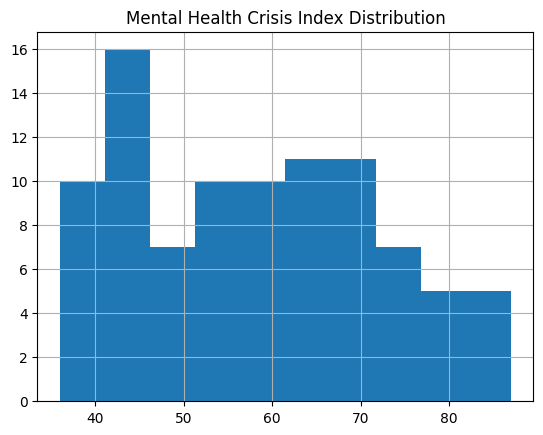

In [3]:
df['mh_crisis_index'].hist()
plt.title("Mental Health Crisis Index Distribution")
plt.show()

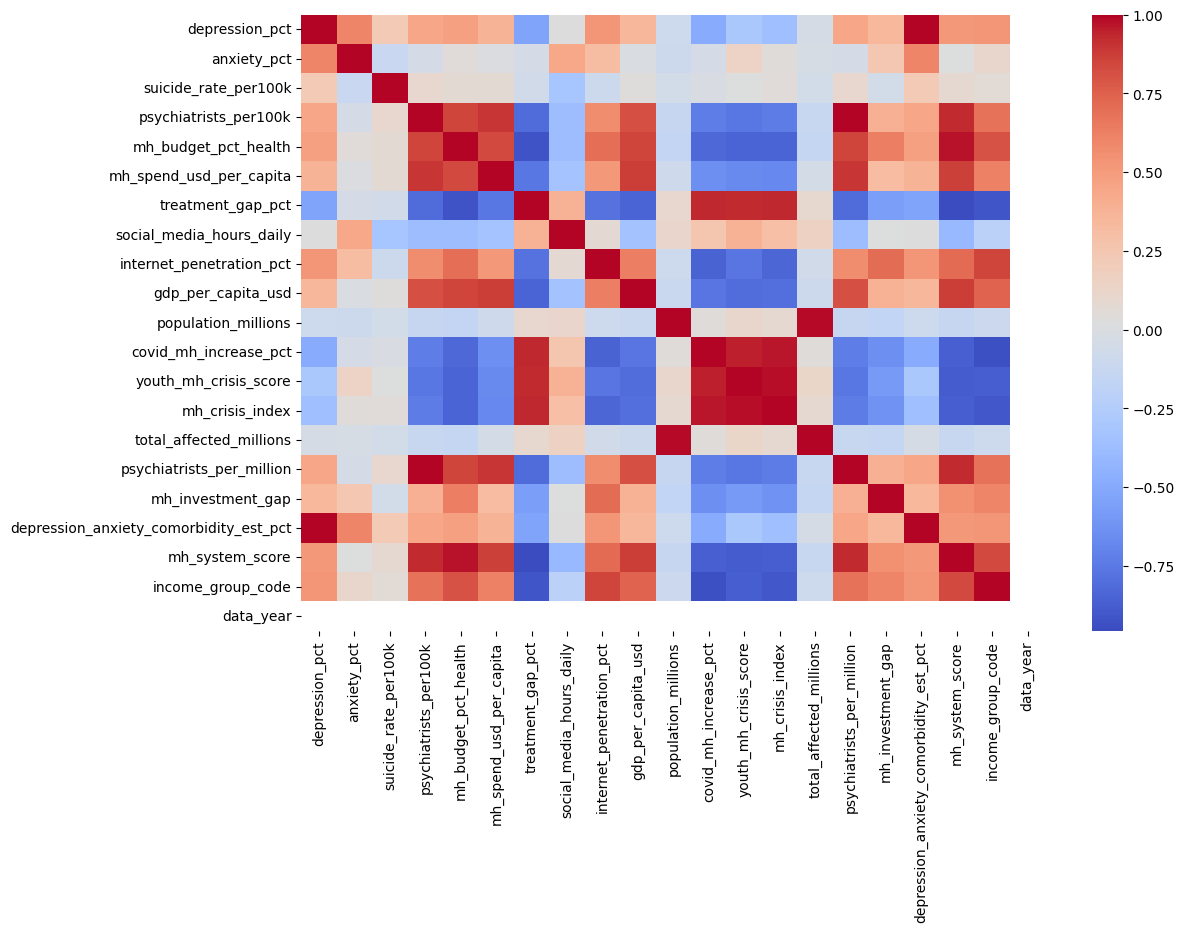

In [4]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [5]:
df.groupby('income_group')['mh_crisis_index'].mean()

income_group
High            44.314286
Low             81.375000
Lower-Middle    68.807692
Upper-Middle    59.652174
Name: mh_crisis_index, dtype: float64

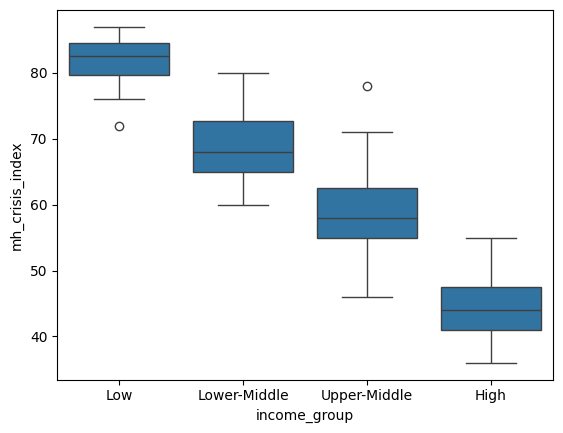

In [6]:
sns.boxplot(x='income_group', y='mh_crisis_index', data=df)
plt.show()

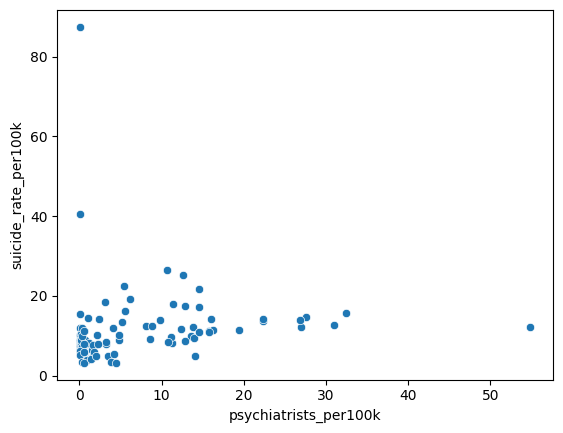

In [7]:
sns.scatterplot(
    x='psychiatrists_per100k',
    y='suicide_rate_per100k',
    data=df
)
plt.show()

<Axes: xlabel='psychiatrists_per100k', ylabel='suicide_rate_per100k'>

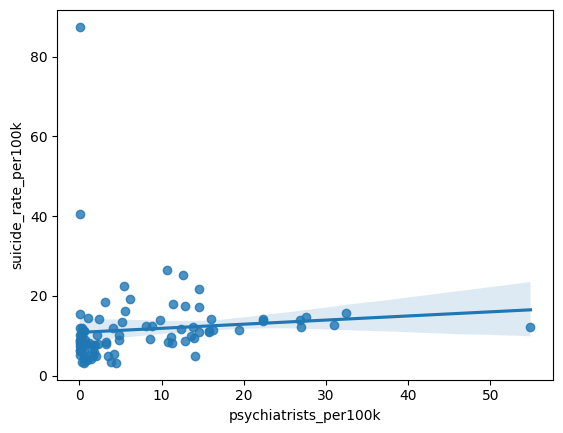

In [8]:
sns.regplot(
    x='psychiatrists_per100k',
    y='suicide_rate_per100k',
    data=df
)

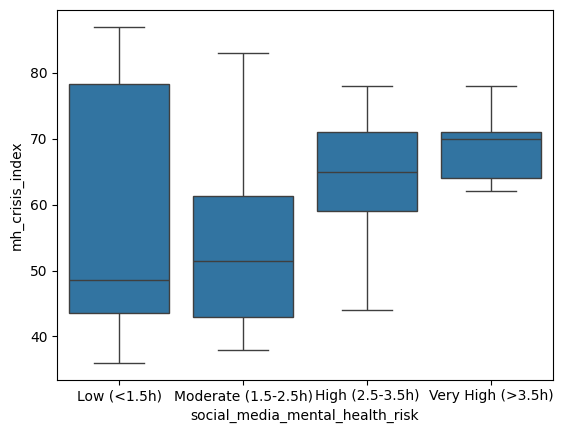

In [9]:
sns.boxplot(
    x='social_media_mental_health_risk',
    y='mh_crisis_index',
    data=df
)
plt.show()

In [10]:
target = 'mh_crisis_index'
features = [
    'psychiatrists_per100k',
    'mh_spend_usd_per_capita',
    'treatment_gap_pct',
    'social_media_hours_daily',
    'gdp_per_capita_usd'
]

df[features + [target]].corr()[target]

psychiatrists_per100k      -0.738680
mh_spend_usd_per_capita    -0.678610
treatment_gap_pct           0.934018
social_media_hours_daily    0.298926
gdp_per_capita_usd         -0.801367
mh_crisis_index             1.000000
Name: mh_crisis_index, dtype: float64

In [11]:
df.isnull().sum()

country                                   0
iso3                                      0
region                                    0
income_group                              0
depression_pct                            0
anxiety_pct                               0
suicide_rate_per100k                      0
psychiatrists_per100k                     0
mh_budget_pct_health                      0
mh_spend_usd_per_capita                   0
treatment_gap_pct                         0
social_media_hours_daily                  0
internet_penetration_pct                  0
gdp_per_capita_usd                        0
population_millions                       0
covid_mh_increase_pct                     0
youth_mh_crisis_score                     0
mh_policy_exists                          0
mh_law_exists                             0
mh_crisis_index                           0
total_affected_millions                   0
psychiatrists_per_million                 0
mh_investment_gap               

In [13]:
df.isnull().sum().sum()

np.int64(0)

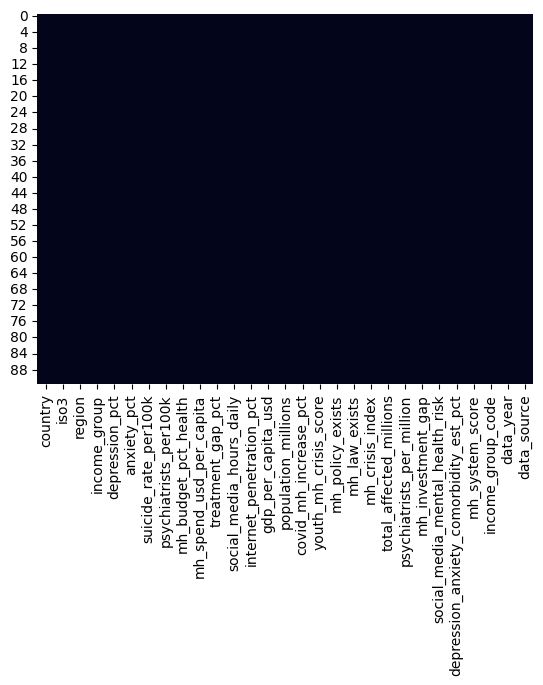

In [14]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()